In [1]:
from lightkurve import search_lightcurve
import numpy as np
import pickle

d:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
import pandas as pd

koi = pd.read_csv("cum_koi_table.csv")

print(koi.columns)
print(koi["koi_disposition"].value_counts())

Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtyp

In [3]:
confirmed = (
    koi[koi["koi_disposition"] == "CONFIRMED"]
    .sample(30, random_state=42)
)

false_positive = (
    koi[koi["koi_disposition"] == "FALSE POSITIVE"]
    .sample(30, random_state=42)
)

candidate = (
    koi[koi["koi_disposition"] == "CANDIDATE"]
    .sample(30, random_state=42)
)

sample_koi = pd.concat(
    [confirmed, false_positive, candidate],
    ignore_index=True
)

print(len(sample_koi))


90


In [4]:
cols = [
    "kepid",
    "koi_disposition"
]

sample_koi = sample_koi[cols]
sample_koi.head()

,kepid,koi_disposition
0,12405333,CONFIRMED
1,8030339,CONFIRMED
2,9964801,CONFIRMED
3,6118370,CONFIRMED
4,9837661,CONFIRMED


In [5]:
from lightkurve import search_lightcurve

kepid = sample_koi.iloc[0]["kepid"]

lc_collection = search_lightcurve(
    f"KIC {int(kepid)}",
    mission="Kepler",
    cadence="long"
).download_all()
lc = (
    lc_collection
    .stitch()
    .remove_nans()
)


In [6]:
print(len(lc.time))
print(len(lc.flux))

64795
64795


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

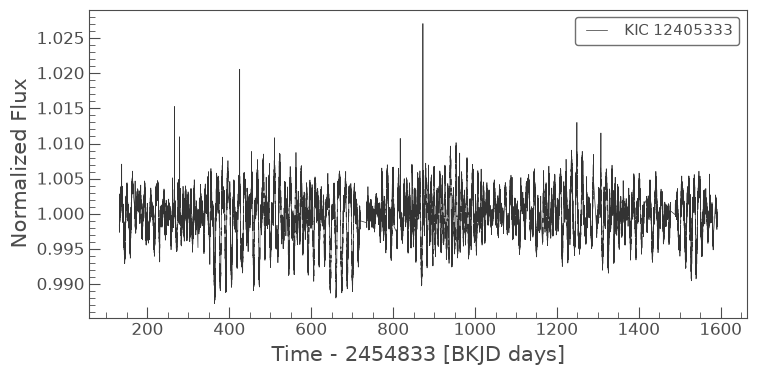

In [7]:
lc.plot()

In [8]:
time = lc.time.value
flux = lc.flux.value

In [9]:
print(time.shape)
print(flux.shape)

(64795,)
(64795,)


In [10]:
import os
import time
import pickle
import numpy as np
from lightkurve import search_lightcurve

CHECKPOINT_FILE = "exoplanet_dataset.pkl"
FAILED_FILE = "failed_kepids.pkl"

# -----------------------
# Load existing progress
# -----------------------

if os.path.exists(CHECKPOINT_FILE):

    with open(CHECKPOINT_FILE, "rb") as f:
        dataset = pickle.load(f)

    print(f"Loaded {len(dataset)} existing samples")

else:

    dataset = []

if os.path.exists(FAILED_FILE):

    with open(FAILED_FILE, "rb") as f:
        failed = pickle.load(f)

else:

    failed = []

# -----------------------
# Already downloaded IDs
# -----------------------

downloaded_ids = set(
    sample["kepid"]
    for sample in dataset
)

print(
    f"Already downloaded: {len(downloaded_ids)}"
)

# -----------------------
# Download loop
# -----------------------

for _, row in sample_koi.iterrows():

    kepid = int(row["kepid"])
    label = row["koi_disposition"]

    if kepid in downloaded_ids:

        print(f"Skipping {kepid}")
        continue

    success = False

    for attempt in range(3):

        try:

            print(
                f"\nDownloading {kepid}"
                f" | Attempt {attempt+1}/3"
            )

            result = search_lightcurve(
                f"KIC {kepid}",
                mission="Kepler",
                cadence="long"
            )

            if len(result) == 0:

                raise Exception(
                    "No light curves found"
                )

            lc_collection = result.download_all()

            lc = (
                lc_collection
                .stitch()
                .remove_nans()
            )

            sample = {

                "kepid": kepid,

                "label": label,

                "time": np.asarray(
                    lc.time.value
                ),

                "flux": np.asarray(
                    lc.flux.value
                )
            }

            dataset.append(sample)

            downloaded_ids.add(kepid)

            # Save immediately

            with open(
                CHECKPOINT_FILE,
                "wb"
            ) as f:

                pickle.dump(
                    dataset,
                    f
                )

            success = True

            print(
                f"SUCCESS {kepid}"
            )

            break

        except Exception as e:

            print(
                f"Attempt {attempt+1} failed"
            )
            print(e)

            time.sleep(5)

    if not success:

        failed.append(kepid)

        with open(
            FAILED_FILE,
            "wb"
        ) as f:

            pickle.dump(
                failed,
                f
            )

        print(
            f"FAILED {kepid}"
        )

    time.sleep(1)

print(
    f"\nFinished."
)
print(
    f"Downloaded: {len(dataset)}"
)
print(
    f"Failed: {len(failed)}"
)

Loaded 68 existing samples
Already downloaded: 68
Skipping 12405333
Skipping 8030339
Skipping 9964801
Skipping 6118370
Skipping 9837661
Skipping 5480640
Skipping 8017703
Skipping 7211141
Skipping 12314973
Skipping 9480189
Skipping 7040629
Skipping 12306058
Skipping 5438757
Skipping 9480189
Skipping 9602613
Skipping 4056616
Skipping 8612275
Skipping 7673192
Skipping 3240158
Skipping 10468885
Skipping 2832589
Skipping 8247638
Skipping 4847534
Skipping 10000941
Skipping 3545135
Skipping 12470954
Skipping 11014932
Skipping 5716932
Skipping 11709244
Skipping 3231341
Skipping 7219906
Skipping 4365461
Skipping 12004680
Skipping 4372765
Skipping 4059887
Skipping 10407210
Skipping 8127586
Skipping 12353720
Skipping 7024045
Skipping 11455795

Attempt 1 failed
Error in reading Data product C:\Users\KUSH\.cache\lightkurve\mastDownload\HLSP\hlsp_iris_kepler_kepler_kplr002438517-stitched_kepler_v1.0_lc\hlsp_iris_kepler_kepler_kplr002438517-stitched_kepler_v1.0_lc.fits of type generic .
This file may

KeyboardInterrupt: 

In [12]:
print(len(dataset))

sample = dataset[0]

print(sample["label"])
print(sample["flux"].shape)
print(sample["time"].shape)

68
CONFIRMED
(64795,)
(64795,)


Class distribution


In [13]:
sample_koi["koi_disposition"].value_counts()

koi_disposition
CONFIRMED         30
FALSE POSITIVE    30
CANDIDATE         30
Name: count, dtype: int64

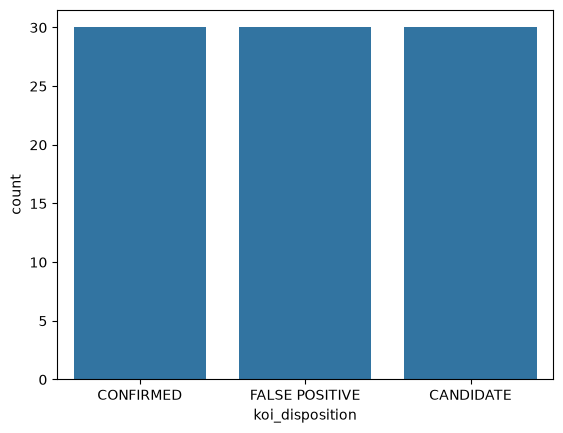

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=sample_koi,
    x="koi_disposition"
)

plt.show()

Transit depth

In [15]:
sample_koi.columns

Index(['kepid', 'koi_disposition'], dtype='object')

In [16]:
confirmed_rows = sample_koi[
    sample_koi["koi_disposition"]=="CONFIRMED"
].head(10)

In [19]:
for _, row in confirmed_rows.iterrows():

    kepid = row["kepid"]

    if kepid not in lc_collection:
        continue

    lc = lc_collection[kepid]

    folded = lc.fold(
        period=row["koi_period"]
    )

    folded.bin(
        time_bin_size=0.01
    ).scatter()

    plt.title(
        f"{kepid} - CONFIRMED"
    )

    plt.show()

In [20]:
koi["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Dataset root
DATASET_DIR = "D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset"

classes = [
    "CONFIRMED",
    "FALSE_POSITIVE",
    "CANDIDATE"
]

N_SAMPLES = 6

for cls in classes:

    folder = os.path.join(DATASET_DIR, cls)

    files = [f for f in os.listdir(folder) if f.endswith(".npz")]

    selected = random.sample(files, min(N_SAMPLES, len(files)))

    fig, axes = plt.subplots(2, 3, figsize=(18,8))
    axes = axes.flatten()

    for ax, file in zip(axes, selected):

        data = np.load(os.path.join(folder, file))

        time = data["time"]
        flux = data["flux"]

        ax.plot(time, flux, lw=0.5)

        ax.set_title(file, fontsize=8)
        ax.set_xlabel("Time")
        ax.set_ylabel("Flux")

    plt.suptitle(cls, fontsize=18)
    plt.tight_layout()
    plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\K'
<>:7: SyntaxWarning: invalid escape sequence '\K'
C:\Users\KUSH\AppData\Local\Temp\ipykernel_12328\3384797947.py:7: SyntaxWarning: invalid escape sequence '\K'
  DATASET_DIR = "D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset"


OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'D:\\Kush\x02nd Year\\Hackathons\\hacktoskill_exoplanet\\dataset\\CONFIRMED'

In [2]:
from pathlib import Path

DATASET_DIR = Path(r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset")

print("Class Distribution")
print("-" * 40)

total = 0
counts = {}

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.npz")))
        counts[class_dir.name] = count
        total += count

for cls, count in counts.items():
    print(f"{cls:<20}: {count:5d} ({count/total*100:.2f}%)")

print("-" * 40)
print("Total:", total)

Class Distribution
----------------------------------------
CANDIDATE           :    53 (20.70%)
CONFIRMED           :    99 (38.67%)
FALSE_POSITIVE      :   104 (40.62%)
----------------------------------------
Total: 256


In [4]:
import os
import random
from pathlib import Path

# ==========================
# CONFIG
# ==========================
DATASET_DIR = Path(r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset")   # Change if needed
EXTENSION = "*.npz"
SEED = 42

random.seed(SEED)

# ==========================
# COUNT FILES
# ==========================
class_files = {}

print("Dataset Summary")
print("-" * 40)

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        files = list(class_dir.glob(EXTENSION))
        class_files[class_dir.name] = files
        print(f"{class_dir.name:<20}: {len(files)}")

# ==========================
# FIND MINIMUM
# ==========================
min_count = min(len(files) for files in class_files.values())

print("\nSmallest class size:", min_count)

# ==========================
# DELETE EXTRAS
# ==========================
deleted = 0

for class_name, files in class_files.items():
    if len(files) > min_count:
        random.shuffle(files)
        extras = files[min_count:]

        for f in extras:
            os.remove(f)
            deleted += 1

        print(f"Deleted {len(extras)} files from {class_name}")

print(f"\nTotal deleted: {deleted}")

# ==========================
# VERIFY
# ==========================
print("\nFinal Counts")
print("-" * 40)

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob(EXTENSION)))
        print(f"{class_dir.name:<20}: {count}")

Dataset Summary
----------------------------------------
CANDIDATE           : 53
CONFIRMED           : 99
FALSE_POSITIVE      : 104

Smallest class size: 53
Deleted 46 files from CONFIRMED
Deleted 51 files from FALSE_POSITIVE

Total deleted: 97

Final Counts
----------------------------------------
CANDIDATE           : 53
CONFIRMED           : 53
FALSE_POSITIVE      : 53
